In [12]:
import numpy as np
from matplotlib import pyplot as plt
data_path = '/media/dhruv/a7519aee-b272-44ae-a117-1f1ea1796db6/2024/arcmg/data/pendulum_lqr/pendulum_roa.txt'
data = np.loadtxt(data_path)[::5, 1:]

data[:, 0] /= np.pi
data[:, 1] /= (2*np.pi)

data.shape

(158131, 3)

In [15]:
from representation_learning.utils.config import ConfigManager
from representation_learning.classifier.trainers.probability_trainer import ProbabilityTrainer
from representation_learning.classifier.data.dataset import ProbabilityDataset
from torch.utils.data import DataLoader
import torch
from tqdm import tqdm
from experiments.systems.pendulum import Pendulum



class PendulumProbabilityDataset(ProbabilityDataset):
    def __init__(self, data, labels, distillation_model, use_representations=True, classifier_model=None):
        self.data = data
        self.labels = labels
        self.distillation_model = distillation_model
        self.use_representations = use_representations
        self.classifier_model = classifier_model
        
        system = Pendulum()
        self.attractors = system.attractors()

config_file = "representation_learning/configs/probability_config.yaml"
config = ConfigManager.load_config(config_file)
probability_trainer = ProbabilityTrainer(config)
probability_trainer.load_checkpoint("outputs/probability_classifier/best_model.pth")
model = probability_trainer.model

# labels = np.array([[attractor_classifications[i][j, 2].item() for i in range(len(attractor_classifications))] for j in range(len(data))])
labels = np.zeros((len(data), 3))
dataset = PendulumProbabilityDataset(data, labels, probability_trainer.distillation_model, use_representations=True, classifier_model=probability_trainer.classifier_model)
dataloader = DataLoader(dataset, batch_size=4096, shuffle=False, pin_memory=True)

2024-12-26 04:07:58,085 - ProbabilityTrainer - INFO - Loading checkpoint from outputs/probability_classifier/best_model.pth
2024-12-26 04:07:58,085 - ProbabilityTrainer - INFO - Loading checkpoint from outputs/probability_classifier/best_model.pth
2024-12-26 04:07:58,085 - ProbabilityTrainer - INFO - Loading checkpoint from outputs/probability_classifier/best_model.pth


representation_learning/configs/probability_config.yaml
outputs/distillation/config.yaml
outputs/5k_diff_balance_small/config.yaml
{'dropout': 0.0, 'hidden_dims': [512, 512, 512], 'input_dim': 128}


In [16]:
raw_data = []
classifier_out = []
prob_out = []
pbar = tqdm(dataloader, desc="Processing dataset")
for i, (raw_inp, inp, label) in enumerate(pbar):
    inp = inp.to(probability_trainer.device)
    with torch.no_grad():
        output = model(inp)
    raw_data.append(raw_inp.numpy())
    classifier_out.append(inp[:, -3:].cpu().numpy())
    prob_out.append(torch.softmax(output, dim=1).squeeze(0).cpu().numpy())

Processing dataset: 100%|██████████| 39/39 [05:33<00:00,  8.55s/it]


In [17]:
raw_data = np.concatenate(raw_data, axis=0)
classifier_out = np.concatenate(classifier_out, axis=0)
prob_out = np.concatenate(prob_out, axis=0)

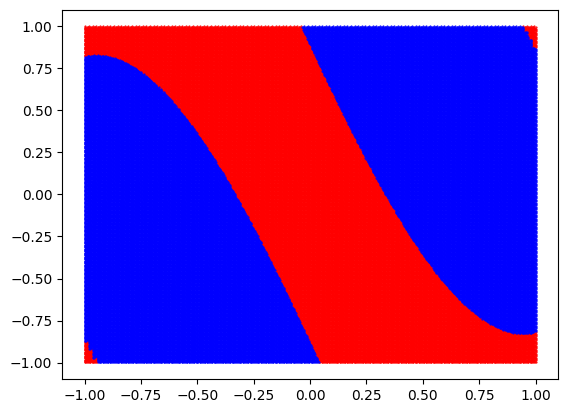

In [18]:
pos = data[data[:, 2] == 1]
neg = data[data[:, 2] == 0]
plt.scatter(pos[:, 0], pos[:, 1], c='r', s=0.3)
plt.scatter(neg[:, 0], neg[:, 1], c='b', s=0.3)

Accuracy: 0.31240553718119785
False positives: 50516
False negatives: 58214
True positives: 2937
True negatives: 46464


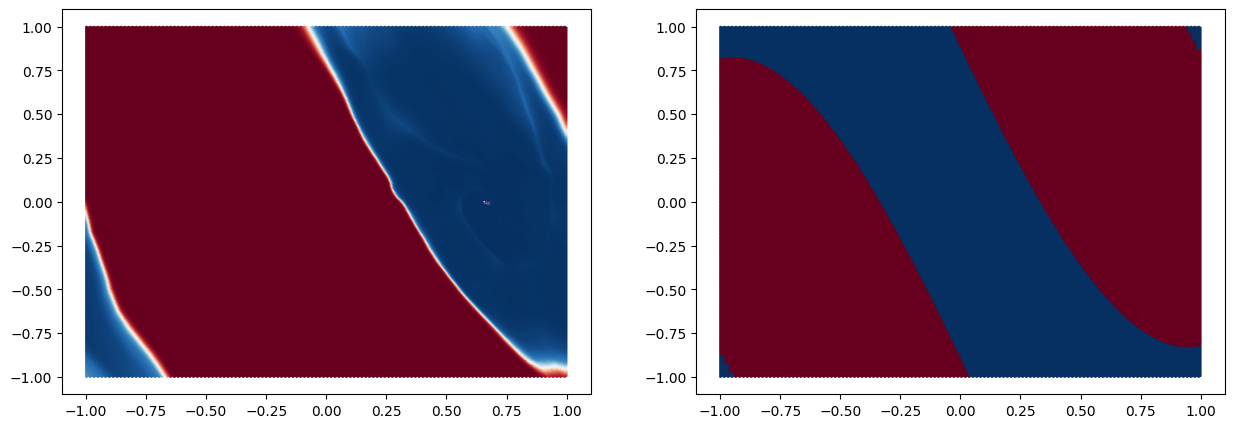

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].scatter(raw_data[:, 0], raw_data[:, 1], c=classifier_out[:, 1], cmap='RdBu', s=0.3)
ax[1].scatter(raw_data[:, 0], raw_data[:, 1], c=data[:, 2], cmap='RdBu', s=0.3)

# accuracy
accuracy = ((classifier_out[:, 1] > 0.5)== data[:, 2]).mean()
print(f'Accuracy: {accuracy}')

# generate false positives, false negatives, true positives, true negatives and plot the matrix
false_positives = np.logical_and(classifier_out[:, 1] > 0.5, data[:, 2] == 0)
false_negatives = np.logical_and(classifier_out[:, 1] < 0.5, data[:, 2] == 1)
true_positives = np.logical_and(classifier_out[:, 1] > 0.5, data[:, 2] == 1)
true_negatives = np.logical_and(classifier_out[:, 1] < 0.5, data[:, 2] == 0)


print(f'False positives: {false_positives.sum()}')
print(f'False negatives: {false_negatives.sum()}')
print(f'True positives: {true_positives.sum()}')
print(f'True negatives: {true_negatives.sum()}')


Accuracy: 0.9865997179553662
False positives: 476
False negatives: 1643
True positives: 59508
True negatives: 96504
precision: 0.9920645505468125
recall: 0.9731320828768132
f1: 0.9825071201551988


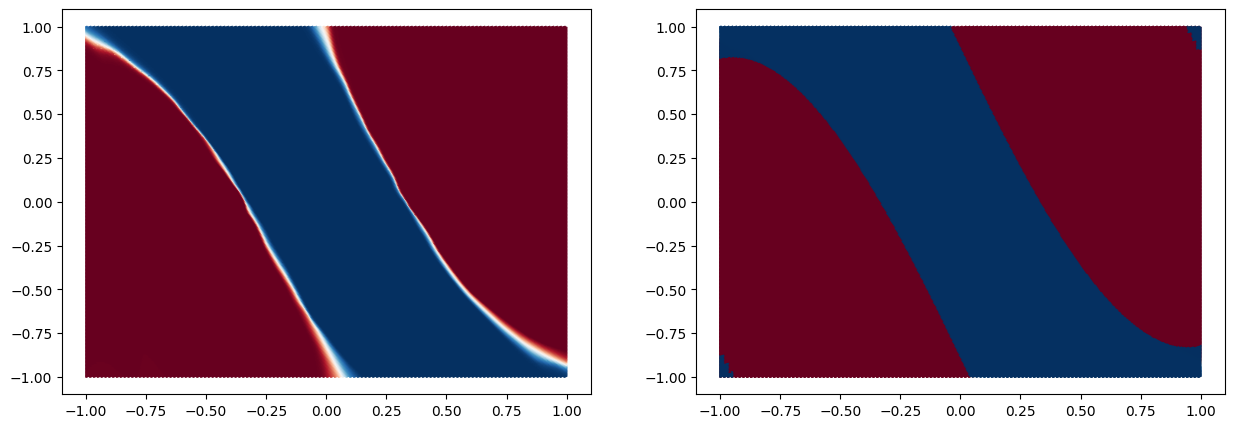

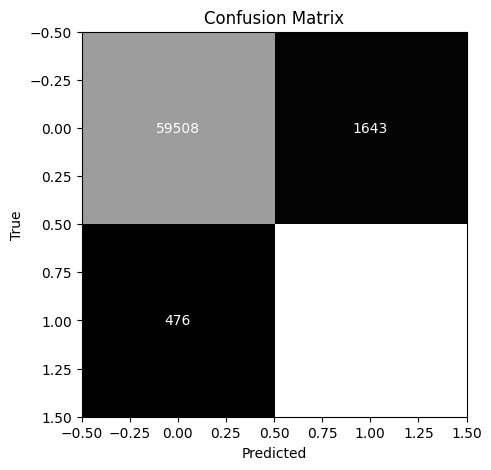

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].scatter(raw_data[:, 0], raw_data[:, 1], c=prob_out[:, 0], cmap='RdBu', s=0.3)

ax[1].scatter(raw_data[:, 0], raw_data[:, 1], c=prob_out[:, 0], cmap='RdBu', s=0.3)
ax[1].scatter(raw_data[:, 0], raw_data[:, 1], c=data[:, 2], cmap='RdBu', s=0.3)

# accuracy
accuracy = ((prob_out[:, 0] > 0.5) == data[:, 2]).mean()
print(f'Accuracy: {accuracy}')

# generate false positives, false negatives, true positives, true negatives and plot the matrix
false_positives = np.logical_and(prob_out[:, 0] > 0.5, data[:, 2] == 0)
false_negatives = np.logical_and(prob_out[:, 0] < 0.5, data[:, 2] == 1)
true_positives = np.logical_and(prob_out[:, 0] > 0.5, data[:, 2] == 1)
true_negatives = np.logical_and(prob_out[:, 0] < 0.5, data[:, 2] == 0)


print(f'False positives: {false_positives.sum()}')
print(f'False negatives: {false_negatives.sum()}')
print(f'True positives: {true_positives.sum()}')
print(f'True negatives: {true_negatives.sum()}')

precision = true_positives.sum() / (true_positives.sum() + false_positives.sum())
recall = true_positives.sum() / (true_positives.sum() + false_negatives.sum())
f1 = 2 * precision * recall / (precision + recall)

print(f'precision: {precision}')
print(f'recall: {recall}')
print(f'f1: {f1}')

# plot the confusion matrix with text
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(np.array([[true_positives.sum(), false_negatives.sum()], [false_positives.sum(), true_negatives.sum()]]), cmap='gray')
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')

for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{np.array([[true_positives.sum(), false_negatives.sum()], [false_positives.sum(), true_negatives.sum()]])[i, j]}', ha='center', va='center', color='white')


Accuracy: 0.9850377218888137
False positives: 1701
False negatives: 665
True positives: 60486
True negatives: 95279
precision: 0.9726470162574171
recall: 0.9891252800444801
f1: 0.9808169420616517


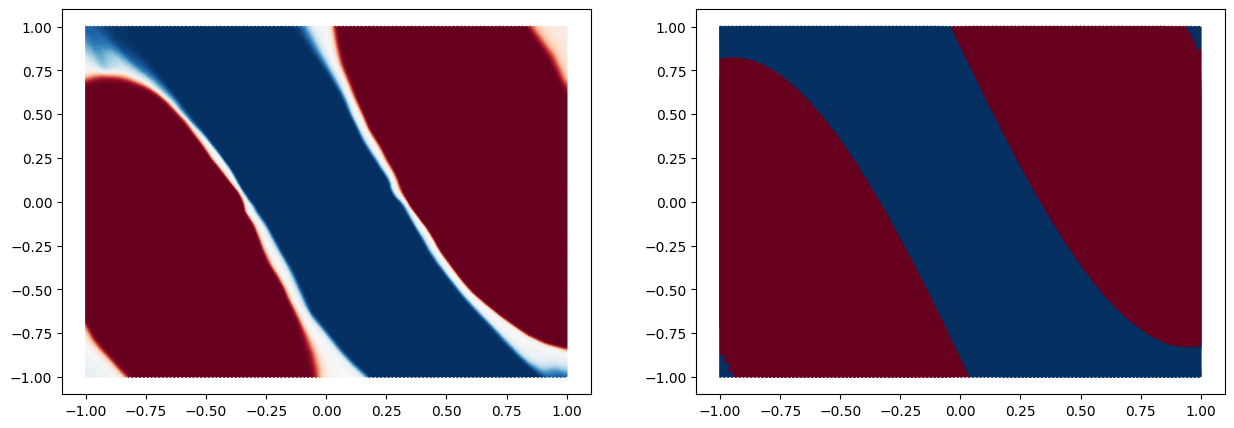

In [21]:
total_prob = classifier_out[:, 0] + classifier_out[:, 1] + classifier_out[:, 2]

norm_probs = {
    i: classifier_out[:, i] / total_prob for i in range(3)
}

norm_probs[1] += norm_probs[2]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].scatter(raw_data[:, 0], raw_data[:, 1], c=norm_probs[0], cmap='RdBu', s=0.3)
ax[1].scatter(raw_data[:, 0], raw_data[:, 1], c=norm_probs[0], cmap='RdBu', s=0.3)
ax[1].scatter(raw_data[:, 0], raw_data[:, 1], c=data[:, 2], cmap='RdBu', s=0.3)


# accuracy
accuracy = ((norm_probs[0] > 0.5)== data[:, 2]).mean()
print(f'Accuracy: {accuracy}')

# generate false positives, false negatives, true positives, true negatives and plot the matrix
false_positives = np.logical_and(norm_probs[0] > 0.5, data[:, 2] == 0)
false_negatives = np.logical_and(norm_probs[0] < 0.5, data[:, 2] == 1)
true_positives = np.logical_and(norm_probs[0] > 0.5, data[:, 2] == 1)
true_negatives = np.logical_and(norm_probs[0] < 0.5, data[:, 2] == 0)


print(f'False positives: {false_positives.sum()}')
print(f'False negatives: {false_negatives.sum()}')
print(f'True positives: {true_positives.sum()}')
print(f'True negatives: {true_negatives.sum()}')

precision = true_positives.sum() / (true_positives.sum() + false_positives.sum())
recall = true_positives.sum() / (true_positives.sum() + false_negatives.sum())
f1 = 2 * precision * recall / (precision + recall)

print(f'precision: {precision}')
print(f'recall: {recall}')
print(f'f1: {f1}')